<a href="https://colab.research.google.com/github/tasosquantumcomputing/Machine-Learning/blob/main/Naive_Bayes_Classifier_Exampe_Breast_Cancer_Winscosin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
cancer = load_breast_cancer()

Data exploration

In [6]:
print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Examine the dimensions

In [7]:
print("shape of the data:",cancer.data.shape)
print("shape of the target:",cancer.target.shape)

shape of the data: (569, 30)
shape of the target: (569,)


feature names

In [8]:
print(cancer.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


target classes

In [9]:
print(cancer.target_names)

['malignant' 'benign']


Dataframe creation

In [10]:
df = pd.DataFrame(cancer.data,columns=cancer.feature_names)
df['target'] = cancer.target

In [11]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


readable class names

In [12]:
df['diagnosis'] = df['target'].map({0:'malignant',1:'benign'})

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [14]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


checking for missing values

In [16]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


class distribution

In [17]:
df['diagnosis'].value_counts()

,count
diagnosis,
benign,357
malignant,212


prior probabilities P(c = maligant)= 212/569 P(c = benign) = 357/569

In [22]:
probs = df["diagnosis"].value_counts(normalize=True)
print(probs)

diagnosis
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


Plot the distribution

<Axes: xlabel='diagnosis'>

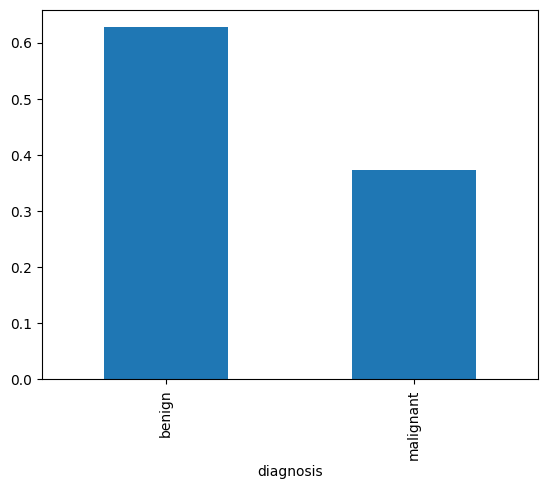

In [23]:
probs.plot(kind = 'bar')

Comprare one feature between the 2 classes

In [24]:
malignant = df[df["diagnosis"] == "malignant"]
benign = df[df["diagnosis"] == "benign"]

print("Mean radius - malignant:")
print(malignant["mean radius"].mean())

print("\nMean radius - benign:")
print(benign["mean radius"].mean())

Mean radius - malignant:
17.462830188679245

Mean radius - benign:
12.146523809523808


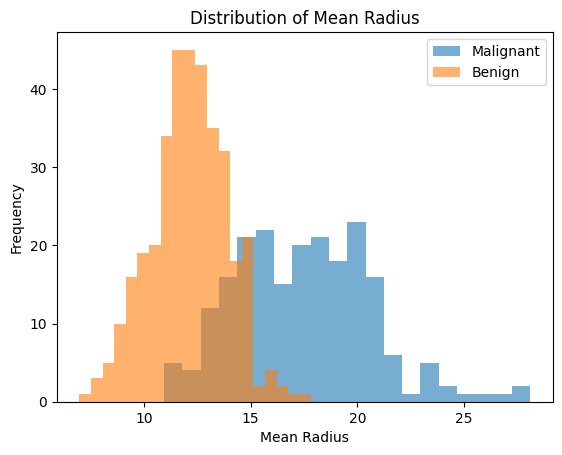

In [25]:
plt.hist(
    malignant["mean radius"],
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.hist(
    benign["mean radius"],
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Radius")
plt.legend()

plt.show()

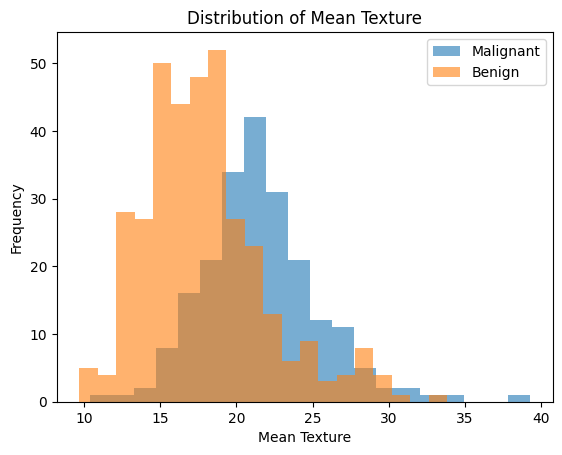

In [28]:
plt.hist(
    malignant["mean texture"],
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.hist(
    benign["mean texture"],
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.xlabel("Mean Texture")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Texture")
plt.legend()

plt.show()

In [29]:
features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

for feature in features:
    malignant_mean = malignant[feature].mean()
    benign_mean = benign[feature].mean()

    print(feature)
    print("Malignant mean:", malignant_mean)
    print("Benign mean:", benign_mean)
    print()

mean radius
Malignant mean: 17.462830188679245
Benign mean: 12.146523809523808

mean texture
Malignant mean: 21.60490566037736
Benign mean: 17.914761904761903

mean perimeter
Malignant mean: 115.36537735849056
Benign mean: 78.075406162465

mean area
Malignant mean: 978.3764150943397
Benign mean: 462.7901960784313

mean smoothness
Malignant mean: 0.10289849056603775
Benign mean: 0.09247764705882354



In [31]:
feature = "mean radius"

print("Malignant")
print("Mean:", malignant[feature].mean())
print("Standard deviation:", malignant[feature].std())

print()

print("Benign")
print("Mean:", benign[feature].mean())
print("Standard deviation:", benign[feature].std())

Malignant
Mean: 17.462830188679245
Standard deviation: 3.2039711007793663

Benign
Mean: 12.146523809523808
Standard deviation: 1.7805116461410389


definition of X and y

In [32]:
X = df.drop(columns=['target','diagnosis'])
y = df['target']

In [33]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [34]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


Train - Test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

statify = εξασφαλιζει οτι η αναλογια 0/1 θα ειναι περιπου ίδια στα 2 subsets

distribution check after the split

In [36]:
print("Training set:")
print(y_train.value_counts(normalize=True))

print()

print("Test set:")
print(y_test.value_counts(normalize=True))

Training set:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test set:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


Creation pf Naive Bayes Classifier

In [38]:
model = GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [39]:
print("Classes:", model.classes_)
print("Class prior probabilities:", model.class_prior_)

Classes: [0 1]
Class prior probabilities: [0.37362637 0.62637363]


το thema περιεχει τα means για καθε class για καθε feature

In [40]:
print(model.theta_)

[[1.73812353e+01 2.15798824e+01 1.14830647e+02 9.66820000e+02
  1.02993941e-01 1.46144824e-01 1.62362882e-01 8.76072353e-02
  1.93630588e-01 6.28292941e-02 5.94710588e-01 1.20105000e+00
  4.23124118e+00 6.98808824e+01 6.79774118e-03 3.24939824e-02
  4.31357059e-02 1.50777235e-02 2.09235235e-02 4.01020588e-03
  2.09670588e+01 2.92767647e+01 1.40258176e+02 1.39677118e+03
  1.44847588e-01 3.78881824e-01 4.63242824e-01 1.82847412e-01
  3.26841176e-01 9.17371176e-02]
 [1.20904281e+01 1.78560351e+01 7.76751228e+01 4.58690526e+02
  9.20954737e-02 7.86516842e-02 4.55483218e-02 2.49237474e-02
  1.72856140e-01 6.28141053e-02 2.82215439e-01 1.22927474e+00
  1.98227825e+00 2.09689649e+01 7.25420351e-03 2.13887860e-02
  2.62396828e-02 9.64176491e-03 2.06925228e-02 3.67027754e-03
  1.33201333e+01 2.34823509e+01 8.65635789e+01 5.54231579e+02
  1.24861649e-01 1.80033649e-01 1.65234375e-01 7.27803895e-02
  2.69405965e-01 7.92964561e-02]]


εχουμε 2 κλασεις και 30 features

In [41]:
print(model.theta_.shape)

(2, 30)


mean of the first feature

In [42]:
print("Feature:", X.columns[0])

print(
    "Mean for malignant:",
    model.theta_[0, 0]
)

print(
    "Mean for benign:",
    model.theta_[1, 0]
)

Feature: mean radius
Mean for malignant: 17.381235294117648
Mean for benign: 12.090428070175433


Variances

In [43]:
print(model.var_.shape)

(2, 30)


In [44]:
print(
    "Variance of mean radius for malignant:",
    model.var_[0, 0]
)

print(
    "Variance of mean radius for benign:",
    model.var_[1, 0]
)

Variance of mean radius for malignant: 9.961219412640872
Variance of mean radius for benign: 3.1070369782585763


**predictions**

In [45]:
y_pred = model.predict(X_test)

In [46]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(15)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


accuracy = correct predictions/total predictions

In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9385964912280702


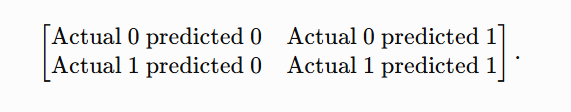

In [48]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 3 69]]


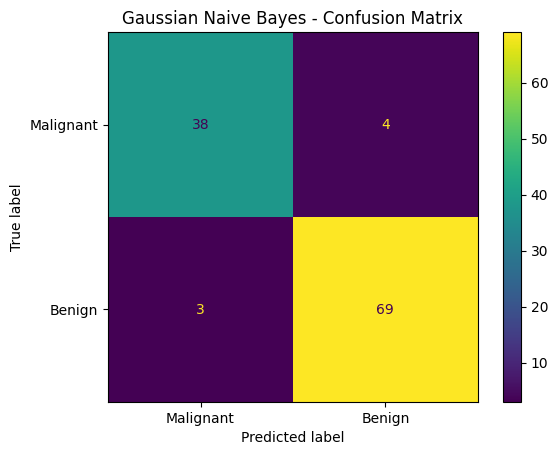

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
).plot()

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

In [50]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.93      0.90      0.92        42
      Benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

